# BMW PRICE PREDICTION AND SALES ANAYLSIS ( 2010 - 2024)


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [31]:


# 1. load the dataset
df = pd.read_csv("BMW sales data (2010-2024) (1).csv")


In [32]:

# 2. show first 5 rows
print("First 5 rows:")
print(df.head())

# 3. show shape
print("\nShape of dataset:")
print(df.shape)

# 4. show column names
print("\nColumn names:")
print(df.columns)

# 5. check missing values
print("\nMissing values:")
print(df.isnull().sum())

# 6. remove missing values
df = df.dropna()

# 7. keep only important columns
df = df[["Model", "Year", "Region", "Fuel_Type", "Transmission",
         "Engine_Size_L", "Mileage_KM", "Price_USD", "Sales_Volume"]]


First 5 rows:
      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0      151748      98740          8300                 High  
1      121671      79219          3428                  Low  
2       10991     113265          6994                  Low  
3       27255      60971          4047                  Low  
4      122131      49898          3080                  Low  

Shape of dataset:
(50000, 11)

Column names:
Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'E

In [33]:

# 8. clean unrealistic values
df = df[df["Year"] >= 2010]
df = df[df["Engine_Size_L"] > 0]
df = df[df["Mileage_KM"] >= 0]
df = df[df["Price_USD"] > 0]
df = df[df["Sales_Volume"] >= 0]

# 9. show shape after cleaning
print("\nShape after cleaning:")
print(df.shape)



Shape after cleaning:
(50000, 9)


In [34]:

# 10. correlation check
df_numeric = df.select_dtypes(include=["number"])
print("\nCorrelation Matrix:")
print(df_numeric.corr())



Correlation Matrix:
                   Year  Engine_Size_L  Mileage_KM  Price_USD  Sales_Volume
Year           1.000000      -0.001944    0.008741   0.003547      0.001671
Engine_Size_L -0.001944       1.000000   -0.004906   0.000146     -0.003942
Mileage_KM     0.008741      -0.004906    1.000000  -0.004238      0.001434
Price_USD      0.003547       0.000146   -0.004238   1.000000      0.000080
Sales_Volume   0.001671      -0.003942    0.001434   0.000080      1.000000


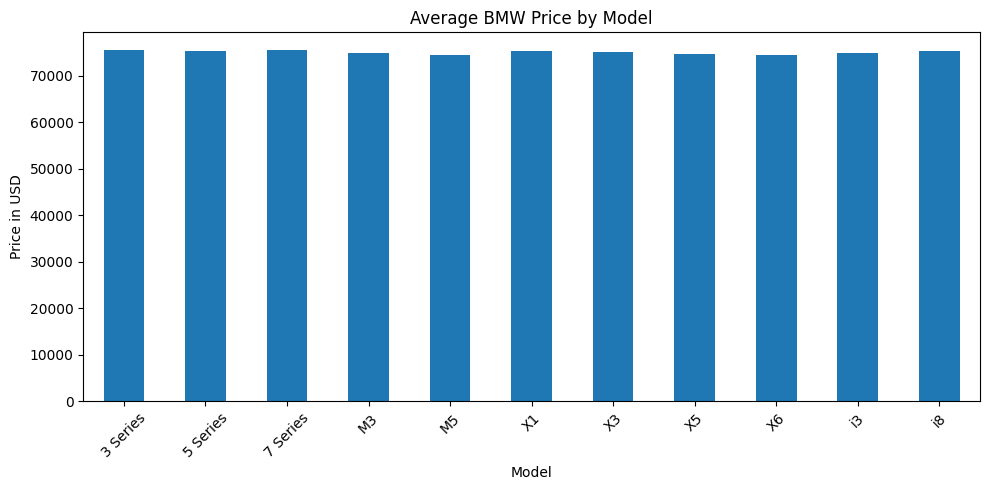

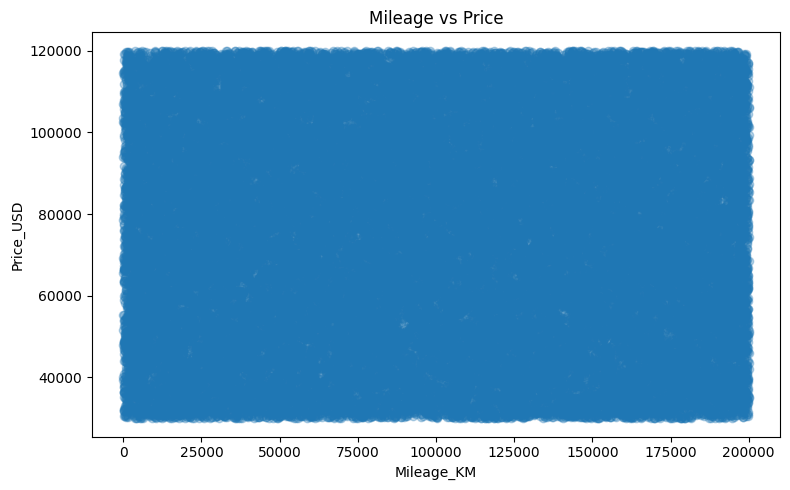

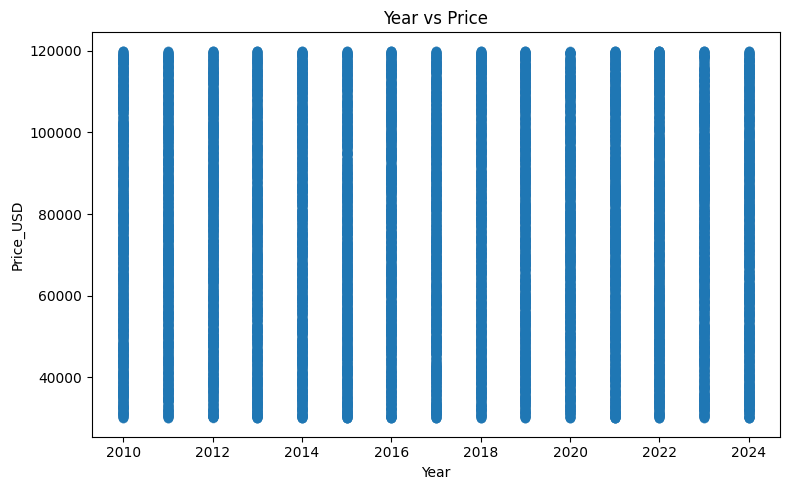

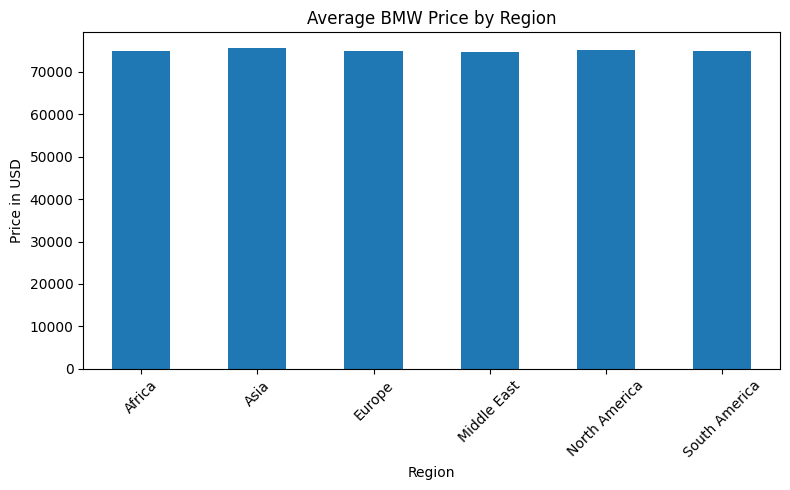

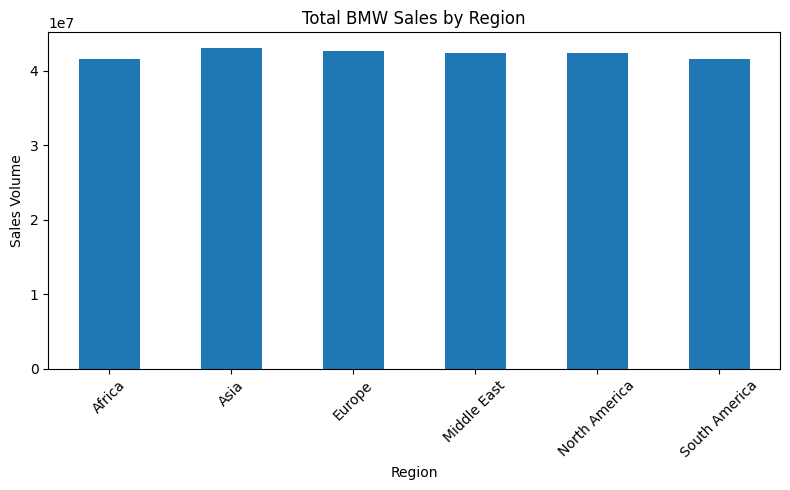

In [35]:

# 11. graph 1: average price by model
avg_price_model = df.groupby("Model")["Price_USD"].mean()
avg_price_model.plot(kind="bar", figsize=(10, 5))
plt.title("Average BMW Price by Model")
plt.xlabel("Model")
plt.ylabel("Price in USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 12. graph 2: mileage vs price
plt.figure(figsize=(8, 5))
plt.scatter(df["Mileage_KM"], df["Price_USD"], alpha=0.3)
plt.title("Mileage vs Price")
plt.xlabel("Mileage_KM")
plt.ylabel("Price_USD")
plt.tight_layout()
plt.show()

# 13. graph 3: year vs price
plt.figure(figsize=(8, 5))
plt.scatter(df["Year"], df["Price_USD"], alpha=0.3)
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price_USD")
plt.tight_layout()
plt.show()

# 14. graph 4: average price by region
avg_price_region = df.groupby("Region")["Price_USD"].mean()
avg_price_region.plot(kind="bar", figsize=(8, 5))
plt.title("Average BMW Price by Region")
plt.xlabel("Region")
plt.ylabel("Price in USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 15. graph 5: total sales by region
sales_region = df.groupby("Region")["Sales_Volume"].sum()
sales_region.plot(kind="bar", figsize=(8, 5))
plt.title("Total BMW Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [36]:

# 16. choose input columns and target
X = df.drop("Price_USD", axis=1)
y = df["Price_USD"]

# 17. change text columns into numbers
X = pd.get_dummies(X, drop_first=True)

# 18. split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [37]:

# 19. linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# 20. decision tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# 21. random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [38]:

# 22. print results
print("\nLinear Regression MAE:", mean_absolute_error(y_test, lr_pred))
print("Linear Regression R2:", r2_score(y_test, lr_pred))

print("\nDecision Tree MAE:", mean_absolute_error(y_test, dt_pred))
print("Decision Tree R2:", r2_score(y_test, dt_pred))

print("\nRandom Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))



Linear Regression MAE: 22572.772098041194
Linear Regression R2: -0.0011786418345141048

Decision Tree MAE: 22729.256020947334
Decision Tree R2: -0.02249603681481105

Random Forest MAE: 22809.388856
Random Forest R2: -0.03431288843077174


In [39]:

# 23. make results table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
               Model           MAE        R2
0  Linear Regression  22572.772098 -0.001179
1      Decision Tree  22729.256021 -0.022496
2      Random Forest  22809.388856 -0.034313
